In [ ]:
import pandas as pd
import numpy as np
import os
import re

In [ ]:
data= pd.read_excel("C:/Users/WQM/Desktop/本科毕业论文/数据集/FNSPID/output3_cleaned.xlsx")
data= pd.DataFrame(data)

In [6]:
data2 = data.sort_values(by=['Date', 'Stock_symbol'], ascending=[True, True])
data2.reset_index(drop= True, inplace= True)

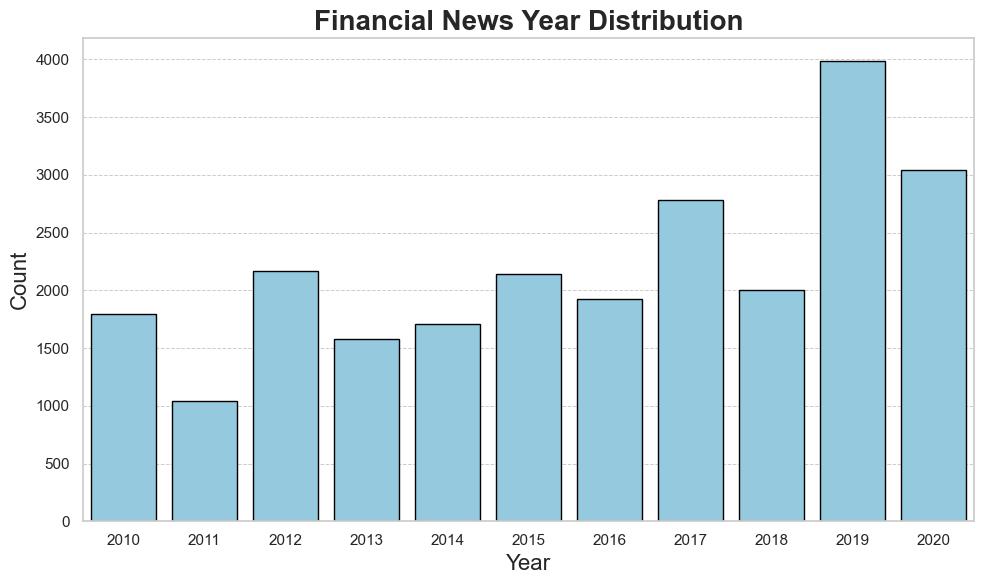

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置 Seaborn 样式为带有虚线网格的背景
sns.set(style="whitegrid", palette="pastel", rc={"grid.linestyle": "--"})

# 将日期转换为年份
data2['Year'] = pd.to_datetime(data2['Date']).dt.year

# 计算每年的计数，并按年份排序
yearly_counts = data2['Year'].value_counts().sort_index()

# 创建图表对象，设置图表尺寸
plt.figure(figsize=(10, 6))

# 绘制柱状图，并设置颜色和边框
ax = sns.barplot(x=yearly_counts.index, y=yearly_counts.values, color='skyblue', edgecolor='black')

# 添加标题和轴标签
plt.title('Financial News Year Distribution', fontsize=20, weight= 'bold')
plt.xlabel('Year', fontsize=16)
plt.ylabel('Count', fontsize=16)

# 添加虚线网格线
plt.grid(axis='y', linestyle='--', linewidth=0.7)


# 保存图表为图片
plt.savefig('Financial News Year Distribution.png', format='png', dpi=300, bbox_inches='tight')

# 自动布局调整，避免标签重叠
plt.tight_layout()

# 显示图表
plt.show()

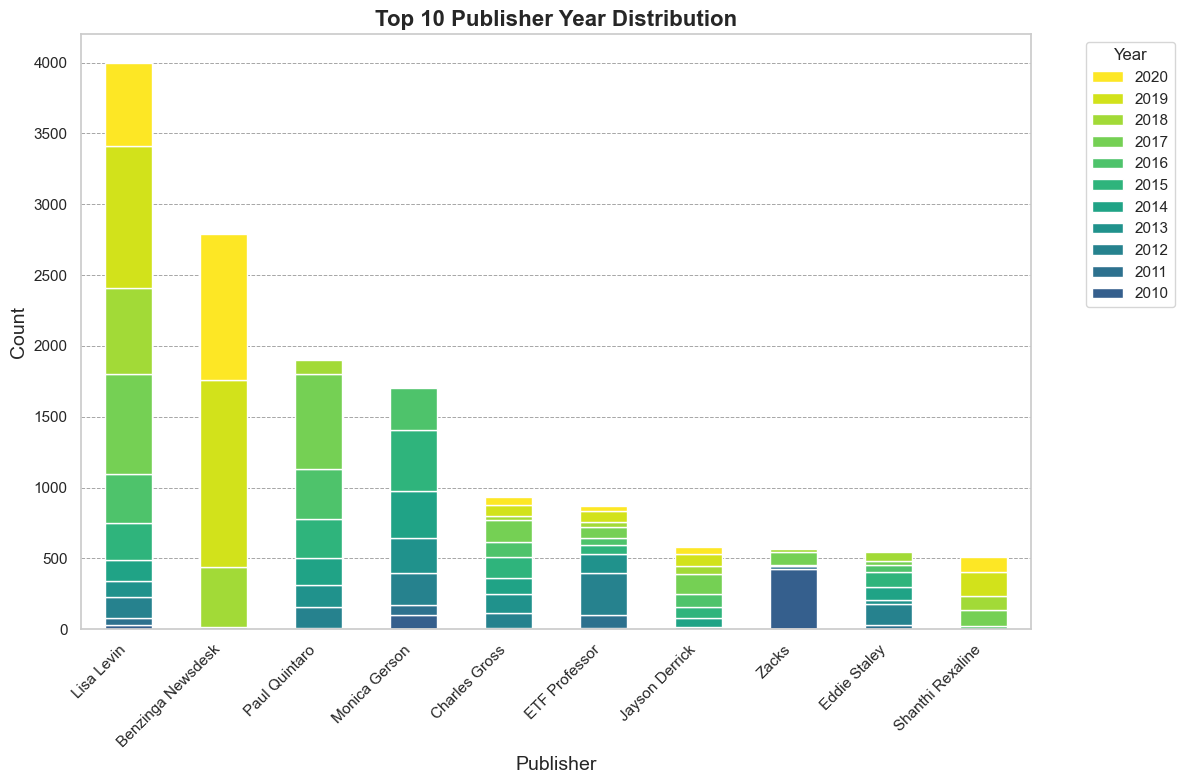

In [38]:
# 计算每个 Publisher 在每一年出现的次数
publisher_year_counts = data2.groupby(['Publisher', 'Year']).size().unstack(fill_value=0)

# 只保留出现次数最多的前 10 个 Publisher
top_publishers = data2['Publisher'].value_counts().head(10).index
publisher_year_counts = publisher_year_counts.loc[top_publishers]

# 获取年份列表
years = publisher_year_counts.columns

# 为不同年份创建渐变色
colors = plt.cm.viridis(np.linspace(0.3, 1, len(years)))

# 绘制堆叠柱状图
ax = publisher_year_counts.plot(kind='bar', stacked=True, figsize=(12, 8), color=colors)

# 添加标题和标签
ax.set_title('Top 10 Publisher Year Distribution', fontsize=16, weight= 'bold')
ax.set_xlabel('Publisher', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# 关闭纵向网格，只保留横向虚线网格
ax.grid(axis='x', visible=False)  # 关闭纵向网格
ax.grid(axis='y', linestyle='--', linewidth=0.7, color='gray', alpha=0.7)  # 添加横向虚线

# 调整图例顺序
handles, labels = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels, handles))  # 将年份与句柄映射
sorted_labels = sorted(legend_dict.keys(), reverse=True)  # 按年份降序排序
sorted_handles = [legend_dict[label] for label in sorted_labels]

# 设置图例在右侧
ax.legend(sorted_handles, sorted_labels, title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

# 调整 X 轴刻度标签显示
plt.xticks(rotation=45, ha='right')

# 保存图表为图片，并确保完整显示
plt.savefig(
    'Top 10 Publisher Year Distribution.png',  # 使用 PNG 格式保存
    format='png',       # 指定图片格式
    dpi=300,            # 提升分辨率
    bbox_inches='tight' # 自动调整边距，避免元素被裁剪
)

# 自动布局调整，避免标签重叠
plt.tight_layout()

# 显示图表
plt.show()

In [10]:
data2.to_excel('output3.xlsx', index= False)

In [39]:
# 计算一列中单词总数
total_words = data2['Article'].apply(lambda x: len(str(x).split())).sum()

print(f"总共有 {total_words} 个单词")

总共有 8792172 个单词


In [29]:
data2

,Date,Stock_symbol,Article_title,Article,Url,Publisher,Year
0,2010-1-1,DRR,Sizemore Capital 2009 Year End Investment Outl...,"As we enter 2010, let us take a moment to refl...",https://www.benzinga.com/74341/sizemore-capita...,Charles Lewis Sizemore CFA,2010
1,2010-1-10,PRXI,Investment Analysis: Premier Exhibitions (PRXI...,Note : For those not familiar with Premier and...,https://www.benzinga.com/100145/investment-ana...,Above Average Odds,2010
2,2010-1-11,AA,"Stock Market News for January 11, 2010 - Marke...",A surprise drop in December nonfarm payrolls h...,https://www.benzinga.com/82688/stock-market-ne...,Zacks,2010
3,2010-1-11,AA,"Stock Watch-List for January 11, 2010",Happy Monday to you all! We have positive bias...,https://www.benzinga.com/82225/stock-watch-lis...,Ryan Mallory,2010
4,2010-1-11,AA,"Benzinga’s Top Pre-Market Gainers (DDSS, IMMU,...",Labopharm Inc. (NASDAQ: DDSS ) increased 4.44%...,https://www.benzinga.com/pre-market-outlook/82...,BenzingaStaff3,2010
...,...,...,...,...,...,...,...
24149,2020-6-9,NMIH,NMI Holdings shares are trading lower after Ke...,Never miss a trade again with the fastest news...,https://www.benzinga.com/wiim/20/06/16212763/n...,Benzinga Newsdesk,2020
24150,2020-6-9,NNVC,NanoViricides Signs Memorandum of Understandin...,Never miss a trade again with the fastest news...,https://www.benzinga.com/general/biotech/20/06...,Benzinga Newsdesk,2020
24151,2020-6-9,SIVR,Gold Isn't The Only Reason This Miners ETF Is ...,Some commodities are getting absolutely wrecke...,https://www.benzinga.com/trading-ideas/long-id...,ETF Professor,2020
24152,2020-6-9,VRML,Vermillion Set To Join Russell 3000 Index,Never miss a trade again with the fastest news...,https://www.benzinga.com/news/20/06/16216740/v...,Benzinga Newsdesk,2020
